In [8]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
from prophet import Prophet
from lightgbm import LGBMRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor

In [9]:
# --- Load Datasets ---
df_2023 = pd.read_csv('/Users/alexanderdagher/Documents/CafeZal/Coffee-Sales-EDA-and-Prediction-main/mother_data - 2023.csv')
df_2024 = pd.read_csv('/Users/alexanderdagher/Documents/CafeZal/Coffee-Sales-EDA-and-Prediction-main/mother_data - 2024:2025.csv')
df = pd.concat([df_2023, df_2024], ignore_index=True)

# --- Datetime Parsing ---
df['Data'] = pd.to_datetime(df['Data'], format='mixed', dayfirst=True, errors='coerce')
df = df.dropna(subset=['Data'])
df['Datetime'] = df['Data'].dt.floor('H')

# --- Filter for Premuda Branch ---
df = df[df['Punto vendita'] == 'CAFEZAL_PREMUDA']

# --- Feature Engineering ---
df['Year'] = df['Data'].dt.year
df['Month'] = df['Data'].dt.month
df['Day'] = df['Data'].dt.day
df['Hour'] = df['Data'].dt.hour
df['Weekday'] = df['Data'].dt.day_name()
df['Is_Weekend'] = df['Weekday'].isin(['Saturday', 'Sunday']).astype(int)
df['Avg_Price'] = df['Totale'] / df['Quantità']

/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_13618/4014253558.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['Datetime'] = df['Data'].dt.floor('H')


In [10]:
# --- Compute Hourly Total Sales by Product ---
df['hourly_total_sales'] = df.groupby(['Hour', 'Nome'])['Totale'].transform('sum')

# --- Monthly Sales per Product ---
df['Month_str'] = df['Data'].dt.to_period('M').astype(str)
df['monthly_sales'] = df.groupby(['Month_str', 'Nome'])['Totale'].transform('sum')

# --- Encode Categorical Variables ---
df['Nome_encoded'] = LabelEncoder().fit_transform(df['Nome'])
df['Weekday_encoded'] = LabelEncoder().fit_transform(df['Weekday'])

# --- Define Features & Target ---
X = df[['Hour', 'Day', 'Month', 'Weekday_encoded', 'hourly_total_sales', 'monthly_sales', 'Nome_encoded']]
y = df['Totale']

In [11]:
# --- Cross-Validation (KFold Standard) ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1)
cv_scores = cross_val_score(rf, X, y, cv=kf, scoring='r2')
print("Random Forest R² CV Scores:", cv_scores)
print("Average R²:", np.mean(cv_scores))
print("Standard Deviation:", np.std(cv_scores))

# --- Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Random Forest R² CV Scores: [0.48019862 0.59473328 0.56321381 0.48633744 0.59374851]
Average R²: 0.5436463301358317
Standard Deviation: 0.05062195656740739


In [12]:
# --- Train Model ---
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=1000, n_jobs=-1, random_state=42)

In [13]:
# --- Predictions ---
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

Random Forest Performance (Premuda - Per Transaction)
--------------------------------------------------------
Train R² Score: 0.8898
Train RMSE: 1.87
Train MAE: 0.64

Test R² Score: 0.5069
Test RMSE: 4.38
Test MAE: 1.25


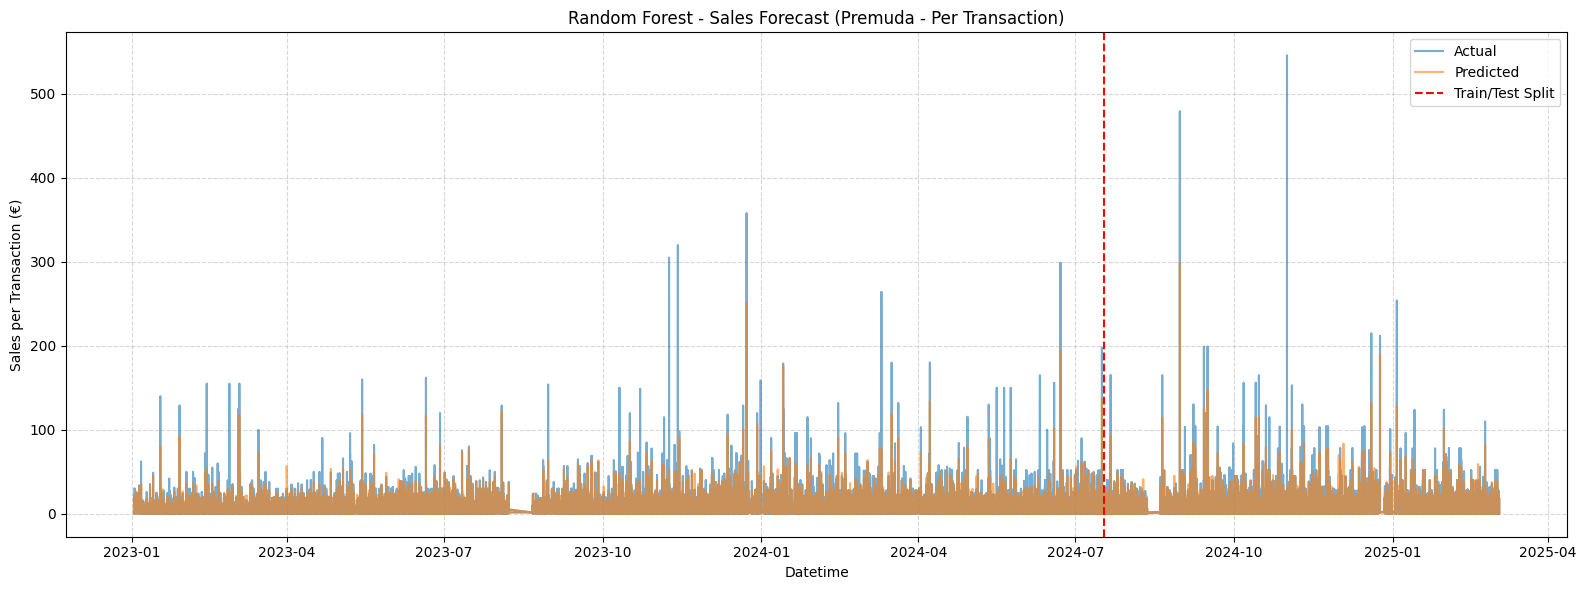

In [14]:
# --- Evaluation Metrics ---
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("Random Forest Performance (Premuda - Per Transaction)")
print("--------------------------------------------------------")
print(f"Train R² Score: {r2_train:.4f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Train MAE: {mae_train:.2f}\n")

print(f"Test R² Score: {r2_test:.4f}")
print(f"Test RMSE: {rmse_test:.2f}")
print(f"Test MAE: {mae_test:.2f}")

# --- Result DataFrame for Visualization ---
result_rf = pd.DataFrame()
result_rf['datetime'] = df['Datetime']
result_rf['Actual'] = y.values
result_rf['Predicted'] = rf_model.predict(X)

# --- Visualization ---
plt.figure(figsize=(16, 6))
plt.plot(result_rf['datetime'], result_rf['Actual'], label='Actual', alpha=0.6)
plt.plot(result_rf['datetime'], result_rf['Predicted'], label='Predicted', alpha=0.6)
plt.axvline(x=result_rf.iloc[len(X_train)].datetime, color='red', linestyle='--', label='Train/Test Split')
plt.title('Random Forest - Sales Forecast (Premuda - Per Transaction)')
plt.xlabel('Datetime')
plt.ylabel('Sales per Transaction (€)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Branch-to-Branch Correlation Matrix:
Punto vendita        CAFEZAL_CSO_MAGENTA  CAFEZAL_PREMUDA  CAFEZAL_SOLFERINO  \
Punto vendita                                                                  
CAFEZAL_CSO_MAGENTA             1.000000         0.567105           0.436743   
CAFEZAL_PREMUDA                 0.567105         1.000000           0.645032   
CAFEZAL_SOLFERINO               0.436743         0.645032           1.000000   
CAFEZAL_S_GREGORIO              0.263427         0.246345           0.106478   

Punto vendita        CAFEZAL_S_GREGORIO  
Punto vendita                            
CAFEZAL_CSO_MAGENTA            0.263427  
CAFEZAL_PREMUDA                0.246345  
CAFEZAL_SOLFERINO              0.106478  
CAFEZAL_S_GREGORIO             1.000000  


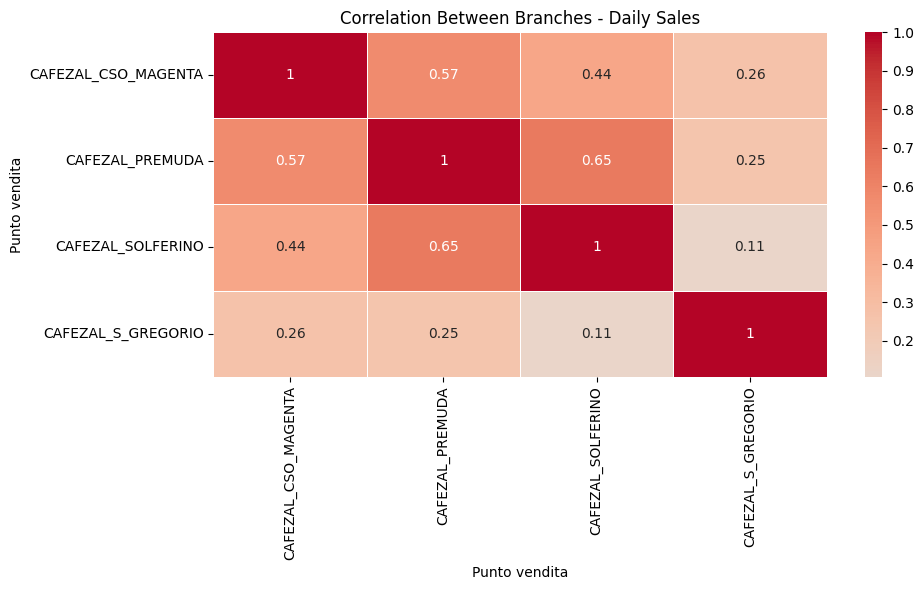

In [15]:
# --- Branch Correlation Analysis ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
file_2023 = '/Users/alexanderdagher/Documents/CafeZal/Coffee-Sales-EDA-and-Prediction-main/mother_data - 2023.csv'
file_2024 = '/Users/alexanderdagher/Documents/CafeZal/Coffee-Sales-EDA-and-Prediction-main/mother_data - 2024:2025.csv'
df_2023 = pd.read_csv(file_2023)
df_2024 = pd.read_csv(file_2024)
df = pd.concat([df_2023, df_2024], ignore_index=True)

# Parse datetime
df['Data'] = pd.to_datetime(df['Data'], format='mixed', dayfirst=True, errors='coerce')
df = df.dropna(subset=['Data'])
df['Date'] = df['Data'].dt.date

# Aggregate daily sales per branch
daily_branch_sales = df.groupby(['Date', 'Punto vendita'])['Totale'].sum().reset_index()

# Pivot to wide format
pivot_df = daily_branch_sales.pivot(index='Date', columns='Punto vendita', values='Totale').fillna(0)

# Correlation matrix
corr_matrix = pivot_df.corr()
print("\nBranch-to-Branch Correlation Matrix:")
print(corr_matrix)

# --- Visualization ---
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Between Branches - Daily Sales')
plt.tight_layout()
plt.show()